<h1>Binary Classification Problem Using All Polish Bankruptcy ARFF Files</h1>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from scipy.io import arff
from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    precision_recall_curve, average_precision_score
)
from sklearn.feature_selection import SelectFromModel
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier



<h3>Loading the data</h3>

In [3]:
from pathlib import Path


data_dir = Path('data/polish+companies+bankruptcy+data')
arff_files = sorted(data_dir.glob('*.arff'))

frames = []
for arff_file in arff_files:
    data, meta = arff.loadarff(arff_file)
    frame = pd.DataFrame(data)
    frame['class'] = frame['class'].astype(int)
    frames.append(frame)


df = pd.concat(frames, ignore_index=True)

print(f'Loaded {len(arff_files)} ARFF files: {[file.name for file in arff_files]}')
print(f'Dataset shape: {df.shape}')
print(f'\nFeatures: {df.shape[1] - 1}')
print(f'Samples : {df.shape[0]}')
print('\nClass distribution (0 = Healthy, 1 = Bankrupt):')
print(df['class'].value_counts())
print(f'\nClass imbalance ratio: {round(df["class"].value_counts()[0] / df["class"].value_counts()[1], 1)}:1')
df.head()

Loaded 5 ARFF files: ['1year.arff', '2year.arff', '3year.arff', '4year.arff', '5year.arff']
Dataset shape: (43405, 65)

Features: 64
Samples : 43405

Class distribution (0 = Healthy, 1 = Bankrupt):
class
0    41314
1     2091
Name: count, dtype: int64

Class imbalance ratio: 19.8:1


,Attr1,Attr2,Attr3,Attr4,Attr5,Attr6,Attr7,Attr8,Attr9,Attr10,...,Attr56,Attr57,Attr58,Attr59,Attr60,Attr61,Attr62,Attr63,Attr64,class
0,0.200550,0.37951,0.39641,2.0472,32.3510,0.38825,0.249760,1.33050,1.1389,0.50494,...,0.121960,0.39718,0.87804,0.001924,8.4160,5.1372,82.658,4.4158,7.4277,0
1,0.209120,0.49988,0.47225,1.9447,14.7860,0.00000,0.258340,0.99601,1.6996,0.49788,...,0.121300,0.42002,0.85300,0.000000,4.1486,3.2732,107.350,3.4000,60.9870,0
2,0.248660,0.69592,0.26713,1.5548,-1.1523,0.00000,0.309060,0.43695,1.3090,0.30408,...,0.241140,0.81774,0.76599,0.694840,4.9909,3.9510,134.270,2.7185,5.2078,0
3,0.081483,0.30734,0.45879,2.4928,51.9520,0.14988,0.092704,1.86610,1.0571,0.57353,...,0.054015,0.14207,0.94598,0.000000,4.5746,3.6147,86.435,4.2228,5.5497,0
4,0.187320,0.61323,0.22960,1.4063,-7.3128,0.18732,0.187320,0.63070,1.1559,0.38677,...,0.134850,0.48431,0.86515,0.124440,6.3985,4.3158,127.210,2.8692,7.8980,0


<h2>Missing Values</h2>

Columns with missing values:
        Missing Count  Missing %
Attr37          18984  43.736897
Attr21           5854  13.486925
Attr27           2764   6.367930
Attr60           2152   4.957954
Attr45           2147   4.946435
...               ...        ...
Attr35              8   0.018431
Attr51              8   0.018431
Attr59              7   0.016127
Attr57              7   0.016127
Attr55              1   0.002304

[64 rows x 2 columns]

Total missing values: 41322


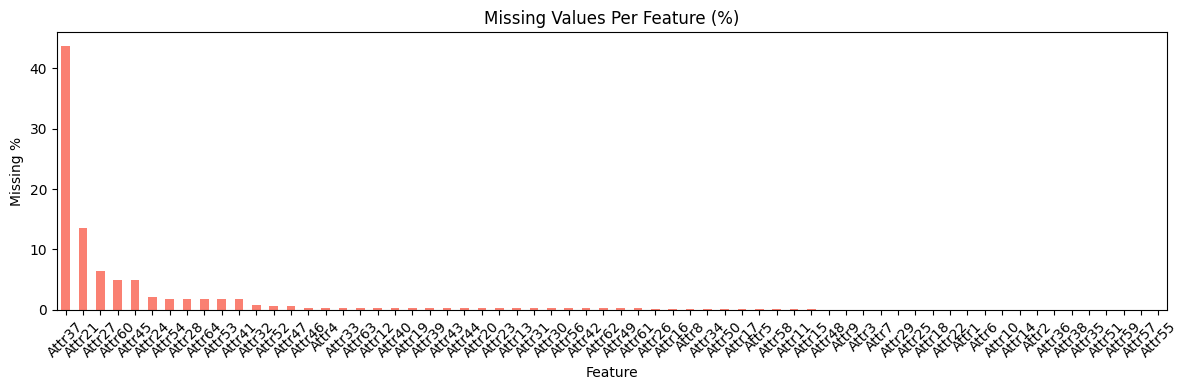

In [4]:
# Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('Columns with missing values:')
print(missing_df)
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

# Plot missing values
plt.figure(figsize=(12, 4))
missing_df['Missing %'].plot(kind='bar', color='salmon')
plt.title('Missing Values Per Feature (%)')
plt.ylabel('Missing %')
plt.xlabel('Feature')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<h2>Addressing the issue Of missing Values</h2>

In [5]:
#  Strategy: Drop columns with >40% missing, fill rest with median 

# Drop high-missing columns
threshold = 40
cols_to_drop = missing_df[missing_df['Missing %'] > threshold].index.tolist()
print(f'Dropping columns with >{threshold}% missing: {cols_to_drop}')
df_clean = df.drop(columns=cols_to_drop)

# Fill remaining missing values with column median
# Median is more robust than mean for financial data (handles outliers)
df_clean = df_clean.fillna(df_clean.median(numeric_only=True))

print(f'\nShape after cleaning: {df_clean.shape}')
print(f'Remaining missing values: {df_clean.isnull().sum().sum()}')

Dropping columns with >40% missing: ['Attr37']

Shape after cleaning: (43405, 64)
Remaining missing values: 0


<h2>Handling Outliers</h2>

In [6]:
#  Handle extreme outliers using IQR capping 
# Cap outliers at 1st and 99th percentile (Winsorization)

X_raw = df_clean.drop('class', axis=1)
y = df_clean['class']

for col in X_raw.columns:
    p1  = X_raw[col].quantile(0.01)
    p99 = X_raw[col].quantile(0.99)
    X_raw[col] = X_raw[col].clip(lower=p1, upper=p99)

print(' Outlier capping complete (1st-99th percentile)')
print(f'Features available: {X_raw.shape[1]}')

 Outlier capping complete (1st-99th percentile)
Features available: 63


<h2>Class Distribution</h2>

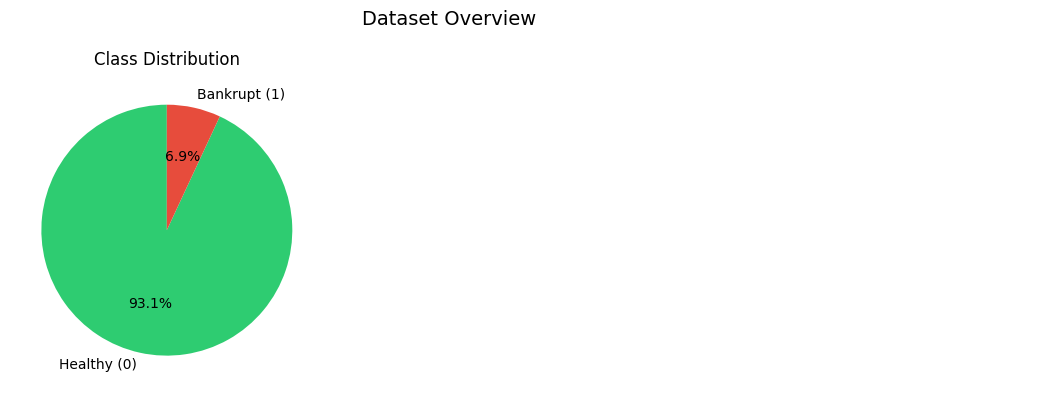

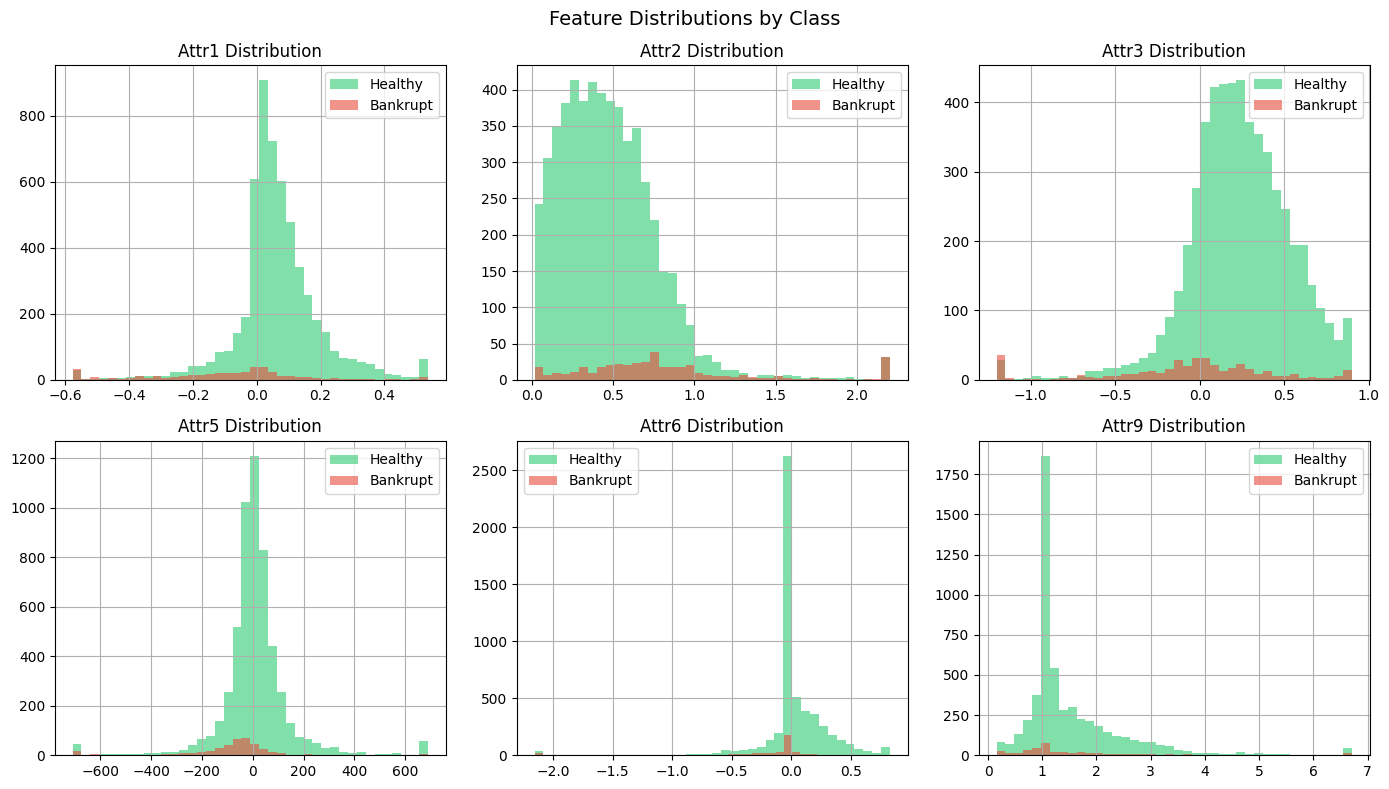

In [6]:
# Class distribution pie chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
y.value_counts().plot.pie(
    ax=axes[0],
    labels=['Healthy (0)', 'Bankrupt (1)'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90
)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('')

# Feature distributions for first 6 features split by class
axes[1].axis('off')
fig.suptitle('Dataset Overview', fontsize=14)
plt.tight_layout()
plt.show()

# Distribution of key financial features by class
key_features = ['Attr1', 'Attr2', 'Attr3', 'Attr5', 'Attr6', 'Attr9']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    if feat in X_raw.columns:
        X_raw[y==0][feat].hist(ax=axes[i], bins=40, alpha=0.6, color='#2ecc71', label='Healthy')
        X_raw[y==1][feat].hist(ax=axes[i], bins=40, alpha=0.6, color='#e74c3c', label='Bankrupt')
        axes[i].set_title(f'{feat} Distribution')
        axes[i].legend()

plt.suptitle('Feature Distributions by Class', fontsize=14)
plt.tight_layout()
plt.show()

<h2>Random Forest Classifier</h2>

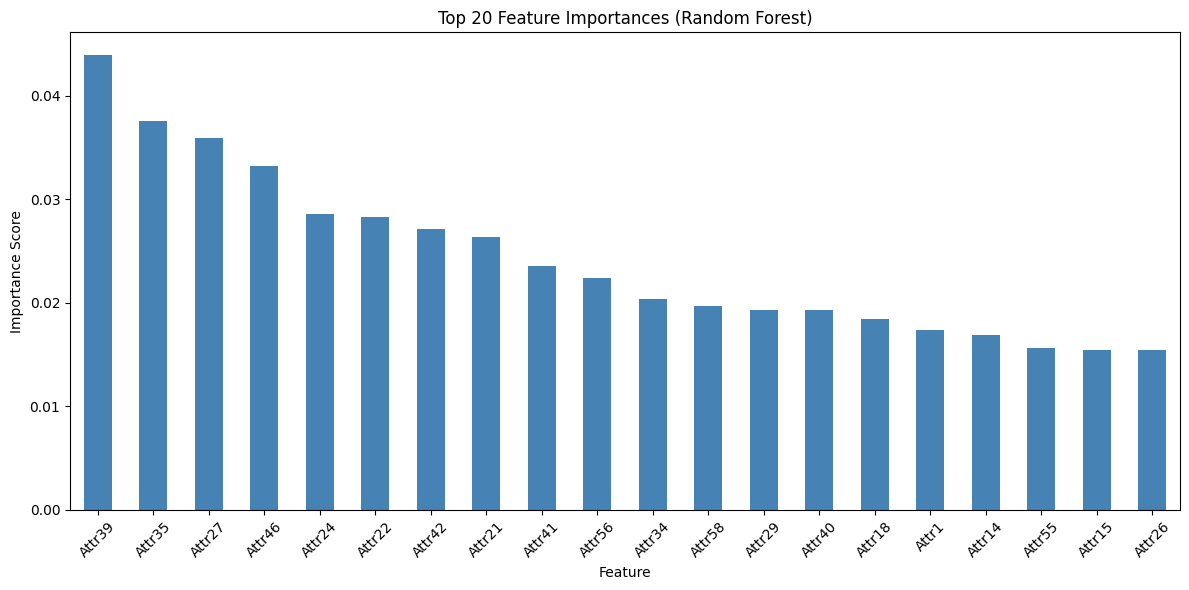

In [ ]:
# Scaling features 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_scaled = pd.DataFrame(X_scaled, columns=X_raw.columns)


# Feature Selection using Random Forest importance
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_scaled, y)

# Get feature importances
importances = pd.Series(rf_selector.feature_importances_, index=X_raw.columns)
importances = importances.sort_values(ascending=False)

# Select top 20 features
top_features = importances.head(20).index.tolist()
X_selected = X_scaled[top_features]

# Plot feature importances
plt.figure(figsize=(12, 6))
importances.head(20).plot(kind='bar', color='steelblue')
plt.title('Top 20 Feature Importances (Random Forest)')
plt.ylabel('Importance Score')
plt.xlabel('Feature')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

print('Train/test split on the full cleaned feature set:')
print(f'  Training set: {X_train_full.shape[0]} samples')
print(f'  Test set    : {X_test_full.shape[0]} samples')
print(f'  Features    : {X_train_full.shape[1]}')
print(f'  Class distribution in training set: {dict(y_train.value_counts())}')


Train/test split on the full cleaned feature set:
  Training set: 34724 samples
  Test set    : 8681 samples
  Features    : 63
  Class distribution in training set: {0: np.int64(33051), 1: np.int64(1673)}


<h1>Building Various Models With Model-Specific Top-20 Features</h1>

In [8]:
def get_feature_ranking(trained_model, feature_names):
    if hasattr(trained_model, 'feature_importances_'):
        scores = trained_model.feature_importances_
    elif hasattr(trained_model, 'coef_'):
        scores = np.abs(np.asarray(trained_model.coef_))
        if scores.ndim > 1:
            scores = scores[0]
    else:
        raise ValueError(f'Unsupported model type for feature ranking: {type(trained_model).__name__}')

    importances = pd.Series(scores, index=feature_names).sort_values(ascending=False)
    top_features = importances.head(20).index.tolist()
    return importances, top_features


def train_model_with_top_features(model_name, model, X_train_base, X_test_base, y_train_base, use_scaler=False):
    train_features = X_train_base.copy()
    test_features = X_test_base.copy()
    scaler = None

    if use_scaler:
        scaler = StandardScaler()
        train_features = pd.DataFrame(
            scaler.fit_transform(train_features),
            columns=X_train_base.columns,
            index=X_train_base.index,
        )
        test_features = pd.DataFrame(
            scaler.transform(test_features),
            columns=X_test_base.columns,
            index=X_test_base.index,
        )

    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(train_features, y_train_base)

    ranking_model = clone(model)
    ranking_model.fit(X_train_res, y_train_res)
    importances, top_features = get_feature_ranking(ranking_model, X_train_res.columns)

    X_train_top = X_train_res[top_features]
    X_test_top = test_features[top_features]

    final_model = clone(model)
    final_model.fit(X_train_top, y_train_res)
    y_pred = final_model.predict(X_test_top)
    y_prob = final_model.predict_proba(X_test_top)[:, 1]

    return {
        'model': final_model,
        'top_features': top_features,
        'importances': importances,
        'X_test': X_test_top,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'f1': f1_score(y_test, y_pred, average='weighted'),
        'roc_auc': roc_auc_score(y_test, y_prob),
        'use_scaler': use_scaler,
    }


models = {
    'Logistic Regression': {'model': LogisticRegression(max_iter=1000, random_state=42), 'use_scaler': True},
    'Gradient Boosting': {'model': GradientBoostingClassifier(n_estimators=100, random_state=42), 'use_scaler': False},
    'Random Forest': {'model': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1), 'use_scaler': False},
    'XGBoost': {'model': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0), 'use_scaler': False},
}

results = {}

for name, spec in models.items():
    results[name] = train_model_with_top_features(
        name,
        spec['model'],
        X_train_full,
        X_test_full,
        y_train,
        use_scaler=spec['use_scaler'],
    )
    print(f'\n{name}')
    print(f'  Selected features: {results[name]["top_features"]}')
    print(f'  F1 Score : {results[name]["f1"]:.4f}')
    print(f'  ROC-AUC  : {results[name]["roc_auc"]:.4f}')



Logistic Regression
  Selected features: ['Attr63', 'Attr1', 'Attr33', 'Attr46', 'Attr26', 'Attr16', 'Attr38', 'Attr8', 'Attr49', 'Attr42', 'Attr51', 'Attr23', 'Attr19', 'Attr4', 'Attr48', 'Attr2', 'Attr10', 'Attr7', 'Attr40', 'Attr14']
  F1 Score : 0.7909
  ROC-AUC  : 0.7680

Gradient Boosting
  Selected features: ['Attr6', 'Attr27', 'Attr16', 'Attr39', 'Attr24', 'Attr38', 'Attr34', 'Attr59', 'Attr64', 'Attr46', 'Attr5', 'Attr41', 'Attr44', 'Attr42', 'Attr26', 'Attr13', 'Attr61', 'Attr20', 'Attr56', 'Attr58']
  F1 Score : 0.8931
  ROC-AUC  : 0.8849

Random Forest
  Selected features: ['Attr27', 'Attr6', 'Attr24', 'Attr39', 'Attr34', 'Attr26', 'Attr25', 'Attr46', 'Attr38', 'Attr58', 'Attr16', 'Attr42', 'Attr5', 'Attr13', 'Attr35', 'Attr59', 'Attr15', 'Attr29', 'Attr41', 'Attr64']
  F1 Score : 0.9476
  ROC-AUC  : 0.9184

XGBoost
  Selected features: ['Attr16', 'Attr6', 'Attr39', 'Attr27', 'Attr38', 'Attr34', 'Attr24', 'Attr42', 'Attr59', 'Attr26', 'Attr19', 'Attr22', 'Attr44', 'Attr20'

<h2>Identifying The Best Model</h2>

Best Model: XGBoost

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.98      0.97      0.97      8263
    Bankrupt       0.48      0.61      0.54       418

    accuracy                           0.95      8681
   macro avg       0.73      0.79      0.76      8681
weighted avg       0.96      0.95      0.95      8681



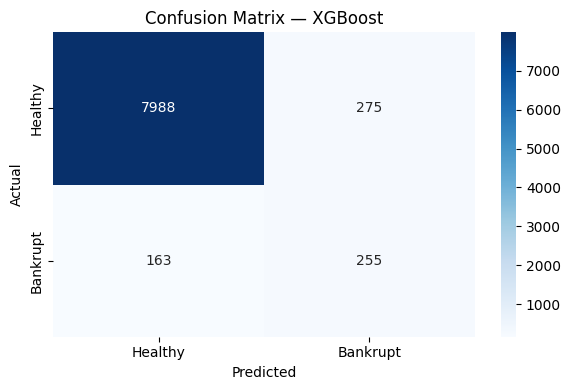

In [9]:
best_model_name = max(results, key=lambda x: results[x]['roc_auc'])
best_model = results[best_model_name]['model']
best_X_test = results[best_model_name]['X_test']

print(f'Best Model: {best_model_name}')
print('\nClassification Report:')
print(classification_report(y_test, results[best_model_name]['y_pred'], target_names=['Healthy', 'Bankrupt']))

cm = confusion_matrix(y_test, results[best_model_name]['y_pred'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Bankrupt'],
            yticklabels=['Healthy', 'Bankrupt'])
plt.title(f'Confusion Matrix — {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


<h2>ROC Curves For All Models</h2>

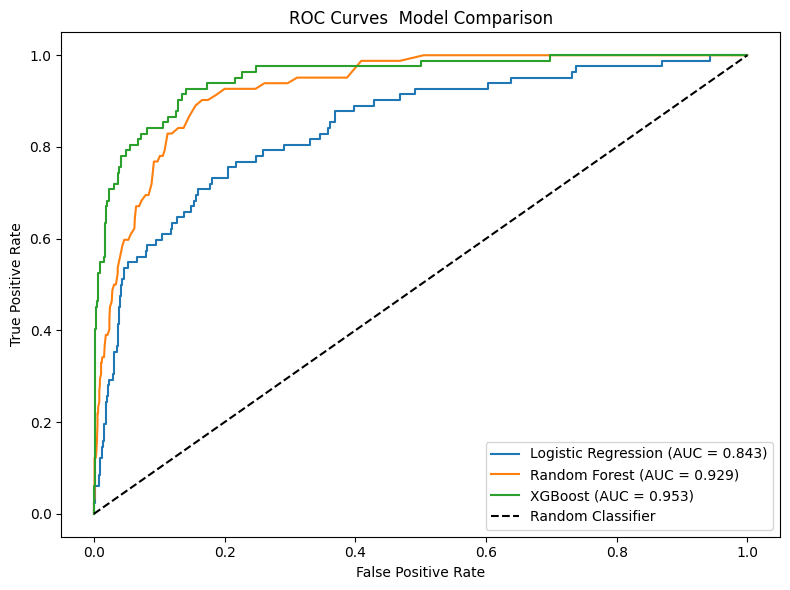

In [ ]:
plt.figure(figsize=(8, 6))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['roc_auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Model Comparison')
plt.legend()
plt.tight_layout()
plt.show()


<h1>Explainable AI Using Shap</h1>

In [10]:
# Use the best model for SHAP explanations
best_model = results[best_model_name]['model']
X_test_model = results[best_model_name]['X_test']
X_background = X_test_model.sample(min(100, len(X_test_model)), random_state=42)

if results[best_model_name]['use_scaler']:
    explainer = shap.Explainer(best_model, X_background)
else:
    explainer = shap.Explainer(best_model, X_background)

shap_values = explainer(X_test_model)
sv = shap_values.values

print(f'SHAP values computed for {best_model_name}')
print(f'  SHAP array shape: {sv.shape}')


100%|===================| 8676/8681 [01:37<00:00]        

SHAP values computed for XGBoost
  SHAP array shape: (8681, 20)


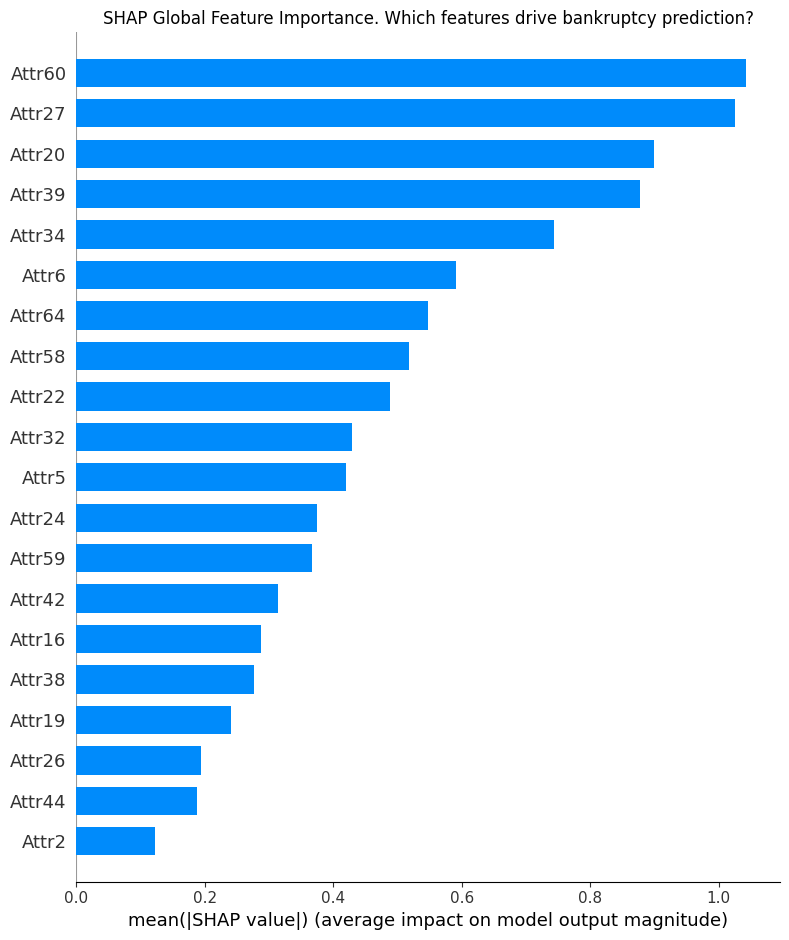

In [11]:
plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_test_model, plot_type='bar', show=False)
plt.title('SHAP Global Feature Importance. Which features drive bankruptcy prediction?')
plt.tight_layout()
plt.show()


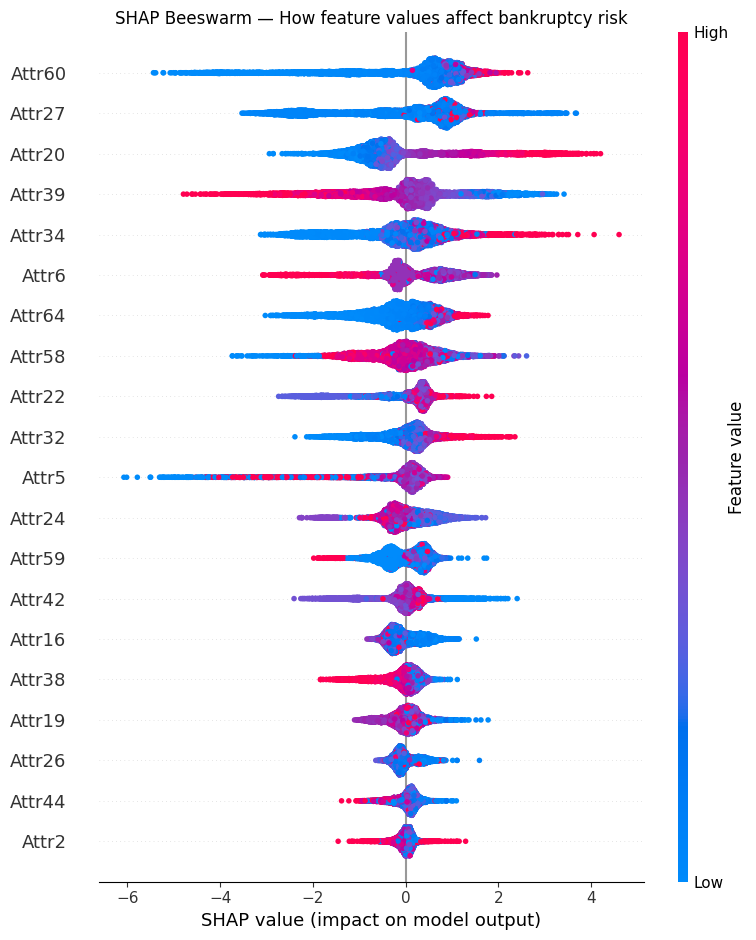

In [12]:
plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_test_model, show=False)
plt.title('SHAP Beeswarm — How feature values affect bankruptcy risk')
plt.tight_layout()
plt.show()


Explaining prediction for test sample index: 28
True label: Bankrupt
Predicted:  Bankrupt


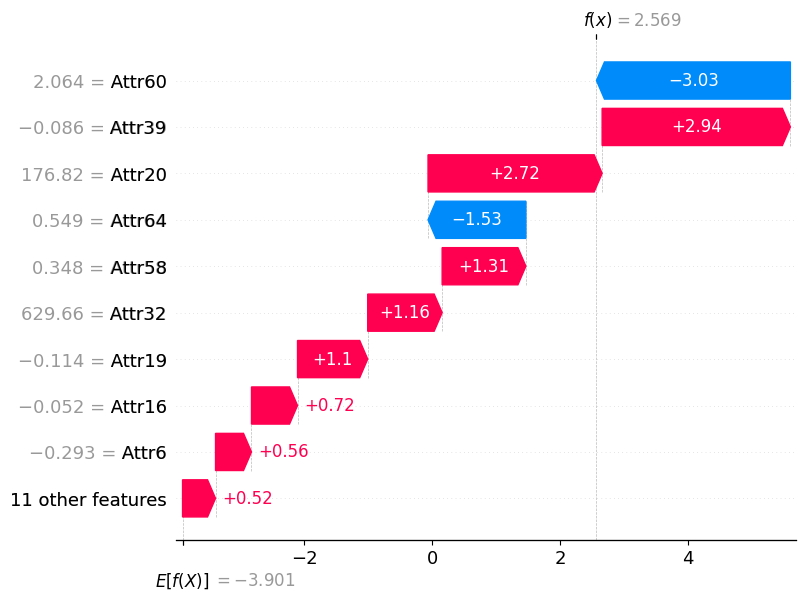

In [13]:
bankrupt_idx = np.where(y_test.values == 1)[0]
if len(bankrupt_idx) > 0:
    sample_idx = bankrupt_idx[0]
    print(f'Explaining prediction for test sample index: {sample_idx}')
    print(f'True label: {"Bankrupt" if y_test.values[sample_idx] == 1 else "Healthy"}')
    print(f'Predicted:  {"Bankrupt" if results[best_model_name]["y_pred"][sample_idx] == 1 else "Healthy"}')

    shap.plots.waterfall(shap_values[sample_idx], show=True)


In [14]:
shap.initjs()
force_plot = shap.force_plot(
    explainer.expected_value,
    sv[sample_idx],
    X_test_model.iloc[sample_idx],
    feature_names=X_test_model.columns.tolist(),
)
force_plot


In [15]:
def explain_bankruptcy_prediction(sample_idx, top_n=5):
    row = X_test_model.iloc[sample_idx]
    shap_row = sv[sample_idx]
    prob = results[best_model_name]['y_prob'][sample_idx]
    pred = results[best_model_name]['y_pred'][sample_idx]

    contributions = pd.Series(shap_row, index=X_test_model.columns).sort_values(key=np.abs, ascending=False)
    top_contrib = contributions.head(top_n)

    print(f'Company prediction explanation for test sample {sample_idx}')
    print(f'Model prediction: {"Bankrupt" if pred == 1 else "Healthy"}')
    print(f'Bankruptcy probability: {prob:.3f}')
    print('\nTop drivers:')

    for feature, shap_value in top_contrib.items():
        direction = 'increases bankruptcy risk' if shap_value > 0 else 'decreases bankruptcy risk'
        feature_value = row[feature]
        print(f'- {feature}: value={feature_value:.4f}, SHAP={shap_value:.4f} -> {direction}')

    risky = top_contrib[top_contrib > 0]
    protective = top_contrib[top_contrib < 0]

    if len(risky) > 0:
        print('\nMain risk factors:')
        for feature, shap_value in risky.items():
            print(f'  - {feature} contributed +{shap_value:.4f} toward bankruptcy')

    if len(protective) > 0:
        print('\nMain protective factors:')
        for feature, shap_value in protective.items():
            print(f'  - {feature} contributed {shap_value:.4f} toward a healthy prediction')


if len(bankrupt_idx) > 0:
    print('TEXT EXPLANATION')
    explain_bankruptcy_prediction(sample_idx)


TEXT EXPLANATION
Company prediction explanation for test sample 28
Model prediction: Bankrupt
Bankruptcy probability: 0.929

Top drivers:
- Attr60: value=2.0643, SHAP=-3.0313 -> decreases bankruptcy risk
- Attr39: value=-0.0858, SHAP=2.9427 -> increases bankruptcy risk
- Attr20: value=176.8200, SHAP=2.7214 -> increases bankruptcy risk
- Attr64: value=0.5487, SHAP=-1.5297 -> decreases bankruptcy risk
- Attr58: value=0.3476, SHAP=1.3092 -> increases bankruptcy risk

Main risk factors:
  - Attr39 contributed +2.9427 toward bankruptcy
  - Attr20 contributed +2.7214 toward bankruptcy
  - Attr58 contributed +1.3092 toward bankruptcy

Main protective factors:
  - Attr60 contributed -3.0313 toward a healthy prediction
  - Attr64 contributed -1.5297 toward a healthy prediction


In [16]:
print('BANKRUPTCY PREDICTION FINAL SUMMARY')

print(f'Dataset       : Polish Companies combined ARFF files')
print(f'Samples       : {df.shape[0]} companies')
print(f'Features used : 20 per model, selected from {X_raw.shape[1]} cleaned features')
print(f'Class balance : {dict(y.value_counts())}')
print(f'Imbalance fix : SMOTE oversampling inside each model path')

print('Model Performance on Test Set:')
for name, res in results.items():
    print(f'  {name:<25} F1={res["f1"]:.4f}  AUC={res["roc_auc"]:.4f}  Top20={res["top_features"][:3]}...')

print(f'Best Model    : {best_model_name}')
print(f'XAI Method    : SHAP')


BANKRUPTCY PREDICTION FINAL SUMMARY
Dataset       : Polish Companies combined ARFF files
Samples       : 43405 companies
Features used : 20 per model, selected from 63 cleaned features
Class balance : {0: np.int64(41314), 1: np.int64(2091)}
Imbalance fix : SMOTE oversampling inside each model path
Model Performance on Test Set:
  Logistic Regression       F1=0.7909  AUC=0.7680  Top20=['Attr63', 'Attr1', 'Attr33']...
  Gradient Boosting         F1=0.8931  AUC=0.8849  Top20=['Attr6', 'Attr27', 'Attr16']...
  Random Forest             F1=0.9476  AUC=0.9184  Top20=['Attr27', 'Attr6', 'Attr24']...
  XGBoost                   F1=0.9524  AUC=0.9240  Top20=['Attr16', 'Attr6', 'Attr39']...
Best Model    : XGBoost
XAI Method    : SHAP
